In [401]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mpl_toolkits.mplot3d import Axes3D

In [402]:
# Mengkoneksikan Colab dengan Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [403]:
path = "/content/drive/MyDrive/Project_Machine_Learning/Praktikum_Mandiri_6/Data/"

# Membaca file CSV menggunakan Pandas
df = pd.read_csv(path + "Titanic.csv" , sep=",")

# Cetak 5 baris awal data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",female,22.0,1,0,A/5 21171,7.2500,E35,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",male,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,A68,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,A81,S


In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [405]:
# Encoding kolom Sex menjadi numerik
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Encoding kolom Cabin menjadi numerik
df['Cabin'] = df['Cabin'].notnull().astype(int)

# Encoding kolom Embarked menjadi numerik
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

In [407]:
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.0,891.000000
mean,446.000000,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208,1.0,1.536476
std,257.353842,0.486592,0.836071,0.477990,13.002015,1.102743,0.806057,49.693429,0.0,0.791503
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.0,0.000000
25%,223.500000,0.000000,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,1.0,1.000000
50%,446.000000,0.000000,3.000000,1.000000,29.699118,0.000000,0.000000,14.454200,1.0,2.000000
75%,668.500000,1.000000,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.0,2.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.0,2.000000


In [408]:
df["Survived"].unique()

array([0, 1])

In [409]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [410]:
# Kolom fitur
X = df[["Pclass", "Sex", "Age", "Fare"]]

# Kolom target (label)
y = df["Survived"]

In [411]:
X.head()

,Pclass,Sex,Age,Fare
0,3,0,22.0,7.2500
1,1,1,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500


In [412]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [413]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [414]:
# Membuat model SVM dengan kernel linear
model = SVC(kernel='linear')

# Melatih model dengan data pelatihan
model.fit(X_train, y_train)

SVC(kernel='linear')

In [415]:
y_pred = model.predict(X_test)
# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Laporan klasifikasi
print("\nLaporan klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 78.21%

Laporan klasifikasi:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179




Confusion Matrix:
 [[88 17]
 [22 52]]


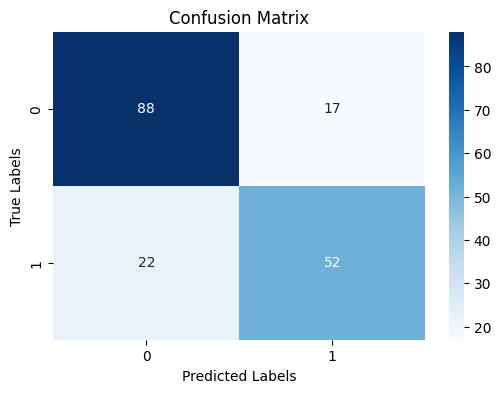

In [416]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

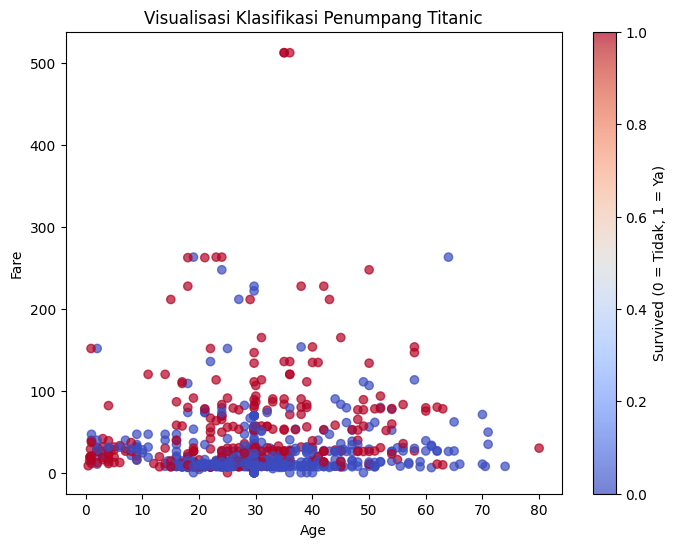

In [418]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(8,6))
plt.scatter(
    df['Age'],
    df['Fare'],
    c=df['Survived'].astype('category').cat.codes,
    cmap='coolwarm',
    alpha=0.7
)

plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Visualisasi Klasifikasi Penumpang Titanic')
plt.colorbar(label='Survived (0 = Tidak, 1 = Ya)')
plt.show()


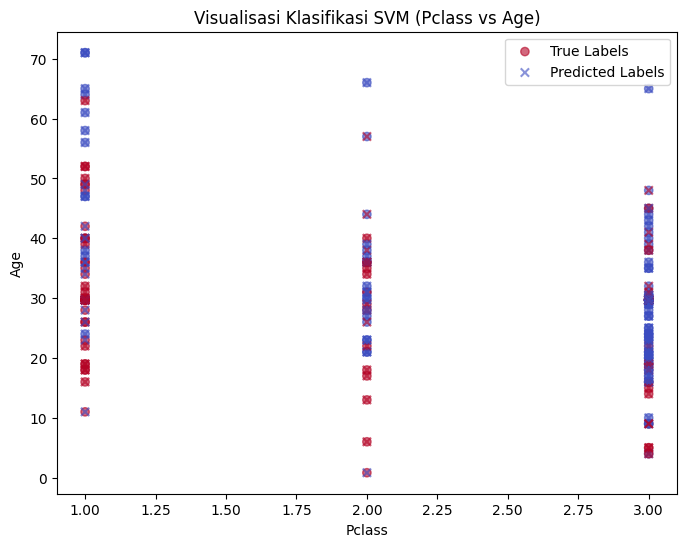

In [419]:
# Pastikan kolom yang digunakan untuk visualisasi
X_test_vis = X_test[['Pclass', 'Age']]

# Encode label (Survived)
le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test)
y_pred_encoded = le.transform(y_pred)

plt.figure(figsize=(8, 6))

# Plot titik berdasarkan label asli
plt.scatter(
    X_test_vis['Pclass'], X_test_vis['Age'],
    c=y_test_encoded, cmap='coolwarm', marker='o',
    label='True Labels', alpha=0.6
)

# Plot titik berdasarkan label hasil prediksi
plt.scatter(
    X_test_vis['Pclass'], X_test_vis['Age'],
    c=y_pred_encoded, cmap='coolwarm', marker='x',
    label='Predicted Labels', alpha=0.6
)

plt.title('Visualisasi Klasifikasi SVM (Pclass vs Age)')
plt.xlabel('Pclass')
plt.ylabel('Age')
plt.legend()
plt.show()


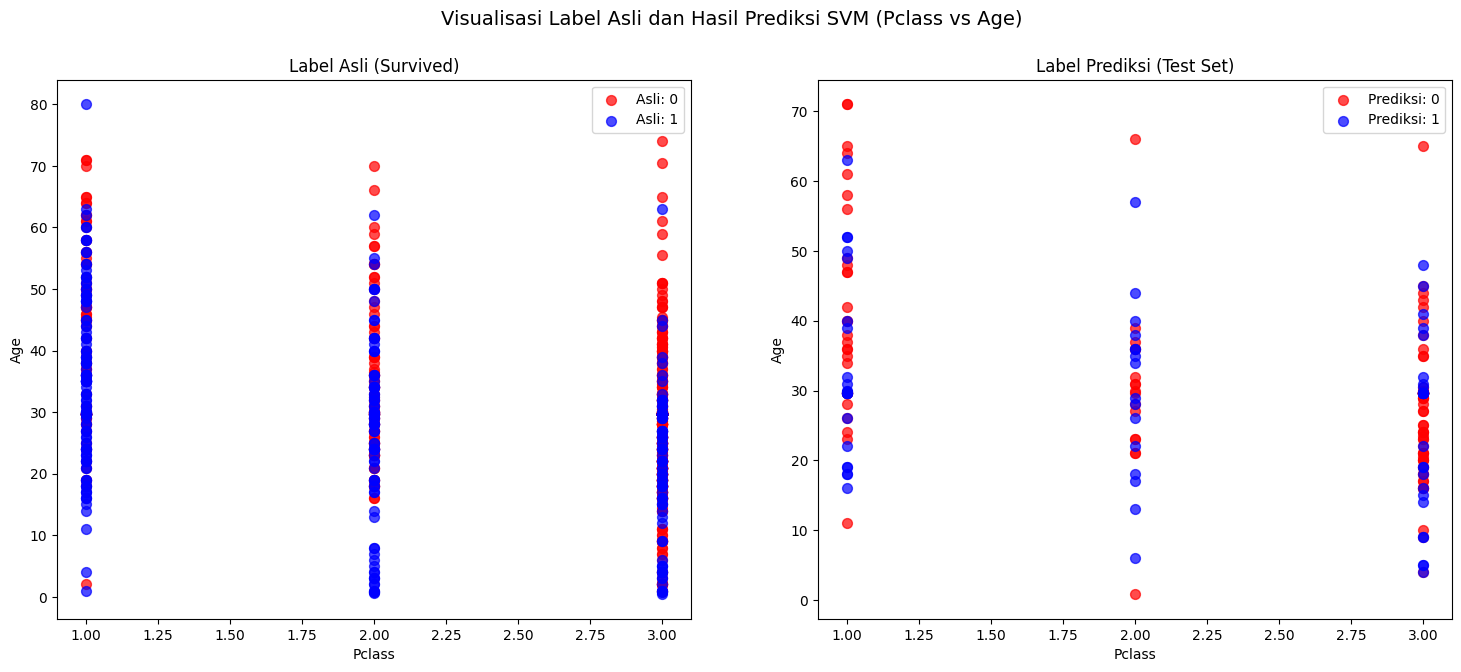

In [420]:
# Encode label 'Survived' (0 atau 1)
le = LabelEncoder()
df['SurvivedEncoded'] = le.fit_transform(df['Survived'])
labels = le.classes_
colors = ['r', 'b']  # misal: merah = tidak selamat, biru = selamat

# Buat figure 2 kolom
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ===== Plot 1: Label Asli =====
for i, label in enumerate(labels):
    subset = df[df['SurvivedEncoded'] == i]
    ax1.scatter(subset['Pclass'], subset['Age'], c=colors[i], label=f"Asli: {label}", s=50, alpha=0.7)

ax1.set_title('Label Asli (Survived)')
ax1.set_xlabel('Pclass')
ax1.set_ylabel('Age')
ax1.legend()

# ===== Plot 2: Label Prediksi =====
# Tambahkan kolom Predicted
df['Predicted'] = None
df.loc[X_test.index, 'Predicted'] = y_pred

# Encode hasil prediksi
df['PredictedEncoded'] = None
df.loc[X_test.index, 'PredictedEncoded'] = le.transform(df.loc[X_test.index, 'Predicted'])

# Plot tiap kelas hasil prediksi
for i, label in enumerate(labels):
    subset = df.loc[X_test.index]
    subset = subset[subset['PredictedEncoded'] == i]
    ax2.scatter(subset['Pclass'], subset['Age'], c=colors[i], label=f"Prediksi: {label}", s=50, alpha=0.7)

ax2.set_title('Label Prediksi (Test Set)')
ax2.set_xlabel('Pclass')
ax2.set_ylabel('Age')
ax2.legend()

plt.suptitle('Visualisasi Label Asli dan Hasil Prediksi SVM (Pclass vs Age)', fontsize=14)
plt.show()


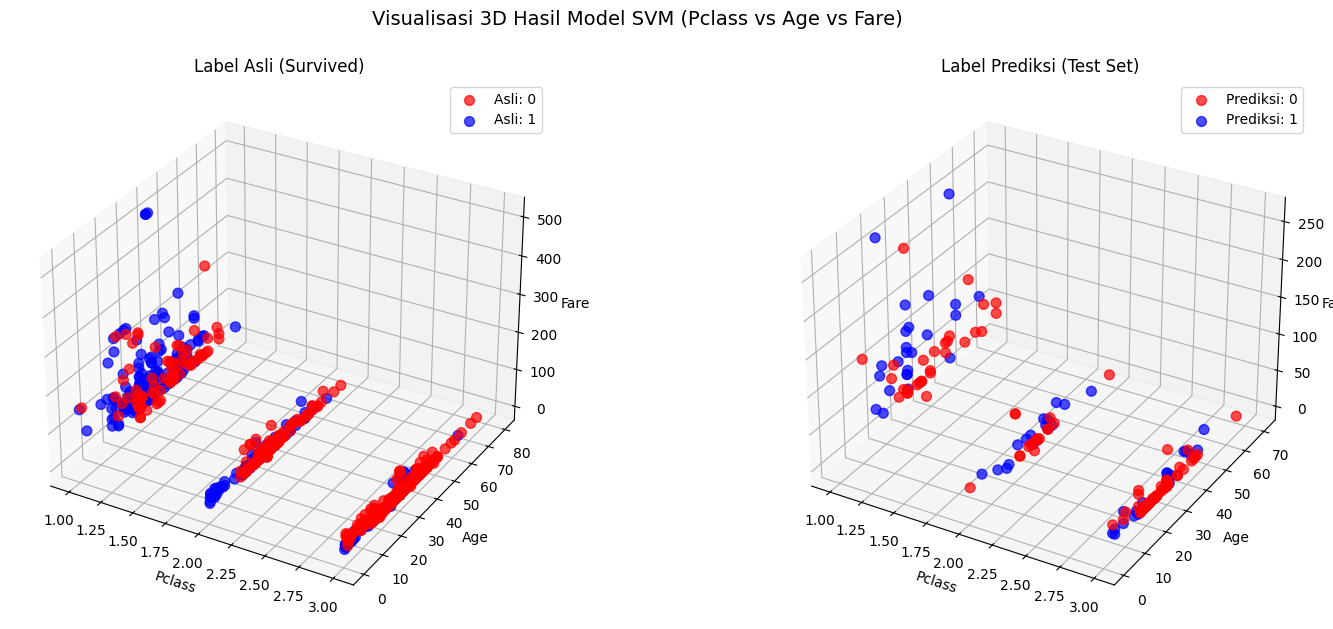

In [421]:
from mpl_toolkits.mplot3d import Axes3D

# Buat figure 3D
fig = plt.figure(figsize=(18, 7))

# =====================
# Plot 1: Label Asli
# =====================
ax1 = fig.add_subplot(121, projection='3d')

for i, label in enumerate(labels):
    subset = df[df['SurvivedEncoded'] == i]
    ax1.scatter(
        subset['Pclass'],
        subset['Age'],
        subset['Fare'],
        c=colors[i],
        label=f"Asli: {label}",
        s=50,
        alpha=0.7
    )

ax1.set_title('Label Asli (Survived)')
ax1.set_xlabel('Pclass')
ax1.set_ylabel('Age')
ax1.set_zlabel('Fare')
ax1.legend()

# =====================
# Plot 2: Label Prediksi
# =====================
ax2 = fig.add_subplot(122, projection='3d')

# Plot hasil prediksi (pada data test)
for i, label in enumerate(labels):
    subset = df.loc[X_test.index]
    subset = subset[subset['PredictedEncoded'] == i]
    ax2.scatter(
        subset['Pclass'],
        subset['Age'],
        subset['Fare'],
        c=colors[i],
        label=f"Prediksi: {label}",
        s=50,
        alpha=0.7
    )

ax2.set_title('Label Prediksi (Test Set)')
ax2.set_xlabel('Pclass')
ax2.set_ylabel('Age')
ax2.set_zlabel('Fare')
ax2.legend()

plt.suptitle('Visualisasi 3D Hasil Model SVM (Pclass vs Age vs Fare)', fontsize=14)
plt.show()
